In [9]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_absolute_error, r2_score, f1_score, classification_report

df = pd.read_csv('tmdb_clustered.csv')
print(df.columns)

Index(['Unnamed: 0', 'vote_average', 'vote_count', 'popularity', 'budget',
       'revenue', 'runtime', 'popularity_normalized', 'vote_count_normalized',
       'popularity_score', 'popularity_category', 'is_popular',
       'rating_category', 'is_highly_rated', 'engagement_score',
       'release_date_year', 'release_date_quarter', 'release_date_month',
       'release_date_day', 'release_date_day_of_week',
       'release_date_week_of_year', 'release_date_day_of_year',
       'release_date_is_month_start', 'release_date_is_month_end',
       'release_date_is_quarter_start', 'release_date_is_quarter_end',
       'release_date_is_year_start', 'release_date_is_year_end',
       'release_date_is_weekend', 'release_date_is_weekday',
       'release_date_decade', 'genres_action', 'genres_crime',
       'genres_thriller', 'genres_animation', 'genres_family',
       'genres_adventure', 'genres_fantasy', 'genres_comedy',
       'genres_science_fiction', 'genres_mystery', 'genres_romance',
   

In [10]:
# Base pre_release features (known before release)
base_features = [
    "budget", "runtime",
    "release_date_year", "release_date_quarter", "release_date_month",
    "release_date_day", "release_date_day_of_week",
    "release_date_week_of_year", "release_date_day_of_year",
    "release_date_is_month_start", "release_date_is_month_end",
    "release_date_is_quarter_start", "release_date_is_quarter_end",
    "release_date_is_year_start", "release_date_is_year_end",
    "release_date_is_weekend", "release_date_is_weekday",
    "release_date_decade",
    "genre_count", "major_studio_count", "has_major_studio",
    "decade", "season",
    "budget_category", "runtime_category",
    "is_summer_release", "is_holiday_release", "is_weekend_release",
    "cluster",
]

# One-hot genre and production company columns
genre_cols = [c for c in df.columns if c.startswith("genres_")]
company_cols = [c for c in df.columns if c.startswith("production_companies_")]
feature_cols = base_features + genre_cols + company_cols

In [11]:
# Target
# Q1 (Regression):continuous profitability
target_reg = 'profitability'
# Q2 (Classification): multi-class profitability category
target_clf = 'profitability_category'

# Regression setup(Q1)
X_reg = df[feature_cols].copy()
y_reg = df[target_reg].copy()

#One-hot encode categorical features
#(season, budget_category, runtime_category are string/object types)
X_reg = pd. get_dummies(
    X_reg,
    columns=["season", "budget_category", "runtime_category"],
    drop_first=True,
)

# Train-test split
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

# Train regression model
reg_model = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)
reg_model.fit(X_train_reg, y_train_reg)
y_pred_reg = reg_model.predict(X_test_reg)

# Evaluate regression model
mae = mean_absolute_error(y_test_reg, y_pred_reg)
r2 = r2_score(y_test_reg, y_pred_reg)

print("Regression Model Evaluation (Q1: profitability):")
print(f"Mean Absolute Error: {mae:.4f}")
print(f"R^2 Score: {r2:.4f}")

# Feature importance for regression
reg_importances = pd.Series(
    reg_model.feature_importances_, index=X_reg.columns
)
reg_importances = reg_importances.sort_values(ascending=True)

print("\nTop 20 Feature Importances (Regression):")
print(reg_importances.head(20))

Regression Model Evaluation (Q1: profitability):
Mean Absolute Error: 3.1320
R^2 Score: 0.2689

Top 20 Feature Importances (Regression):
release_date_is_year_end                     3.908828e-07
genres_tv_movie                              9.545144e-06
budget_category_Mega                         2.244300e-05
genres_western                               5.012477e-05
release_date_is_year_start                   7.474043e-05
production_companies_relativity_media        1.245419e-04
production_companies_dreamworks_pictures     2.421796e-04
budget_category_Medium                       3.843342e-04
release_date_is_month_end                    4.073843e-04
production_companies_columbia_pictures       4.155128e-04
release_date_is_weekday                      4.298133e-04
release_date_is_weekend                      5.470109e-04
genres_family                                6.224676e-04
is_weekend_release                           6.341968e-04
production_companies_walt_disney_pictures    6.3434

In [12]:
# Classification setup(Q2)
X_clf = df[feature_cols].copy()
y_clf = df[target_clf].copy()

X_clf = pd. get_dummies(
    X_clf,
    columns=["season", "budget_category", "runtime_category"],
    drop_first=True,
)

# Train-test split
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

In [13]:
# Train classification model
clf_model = RandomForestClassifier(
    n_estimators=300,
    class_weight='balanced', #hanle imbalanced classes
    random_state=42,
    n_jobs=-1
)

clf_model.fit(X_train_clf, y_train_clf)
y_pred_clf = clf_model.predict(X_test_clf)

# Evaluate classification model
weighted_f1 = f1_score(y_test_clf, y_pred_clf, average='weighted')

print("\nClassification Model Evaluation (Q2: profitability_category):")
print(f"Weighted F1 Score: {weighted_f1:.4f}")
print("\nClassification Report:")
print(classification_report(y_test_clf, y_pred_clf))

# Feature importance for classification
clf_importances = pd.Series(
    clf_model.feature_importances_, index=X_clf.columns
)
clf_importances = clf_importances.sort_values(ascending=False)

print("Top 20 Feature Importances (Classification):")
print(clf_importances.head(20))


Classification Model Evaluation (Q2: profitability_category):
Weighted F1 Score: 0.3739

Classification Report:
                   precision    recall  f1-score   support

       Break_Even       0.25      0.03      0.05        69
Highly_Profitable       0.47      0.78      0.58       296
             Loss       0.31      0.07      0.11        74
       Major_Loss       0.49      0.52      0.51       165
       Profitable       0.07      0.02      0.03       122

         accuracy                           0.45       726
        macro avg       0.32      0.28      0.26       726
     weighted avg       0.37      0.45      0.37       726

Top 20 Feature Importances (Classification):
budget                       0.084638
runtime                      0.076426
release_date_day_of_year     0.073627
release_date_day             0.073010
release_date_year            0.068006
release_date_week_of_year    0.058351
release_date_day_of_week     0.042207
genre_count                  0.037621
rele

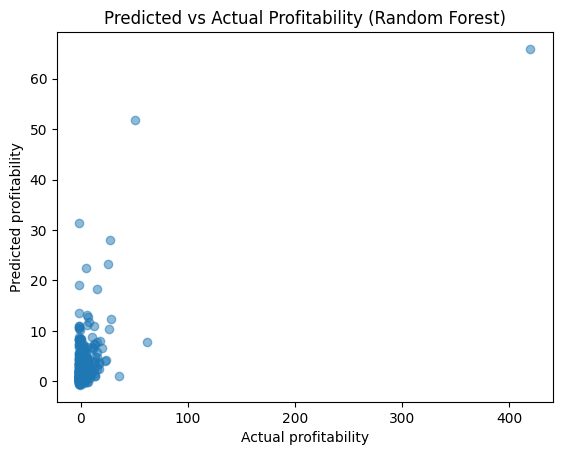

In [14]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(y_test_reg, y_pred_reg, alpha=0.5)
plt.xlabel("Actual profitability")
plt.ylabel("Predicted profitability")
plt.title("Predicted vs Actual Profitability (Random Forest)")
plt.show()


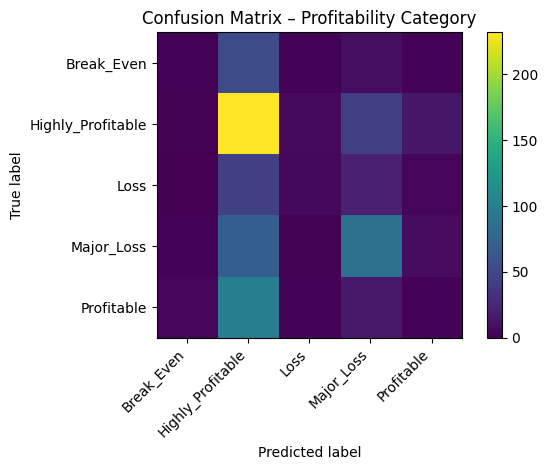

In [15]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

cm = confusion_matrix(y_test_clf, y_pred_clf, labels=clf_model.classes_)

fig, ax = plt.subplots()
im = ax.imshow(cm)

ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_xticks(np.arange(len(clf_model.classes_)))
ax.set_yticks(np.arange(len(clf_model.classes_)))
ax.set_xticklabels(clf_model.classes_, rotation=45, ha="right")
ax.set_yticklabels(clf_model.classes_)

plt.title("Confusion Matrix – Profitability Category")
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()


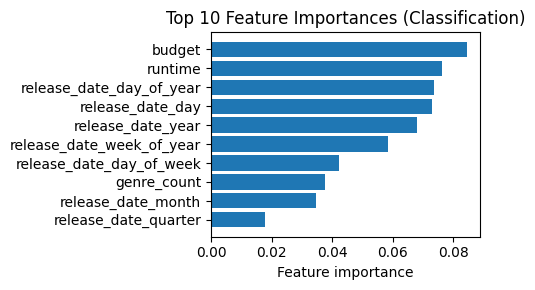

In [20]:
# Q1 Feature Importance Bar Chart
top_k = 10
fi = clf_importances.head(top_k)[::-1]

plt.figure(figsize=(5, 3))
plt.barh(fi.index, fi.values)
plt.xlabel("Feature importance")
plt.title("Top 10 Feature Importances (Classification)")
plt.tight_layout()
plt.show()


Text(0.5, 1.0, 'Distribution of Profitability')

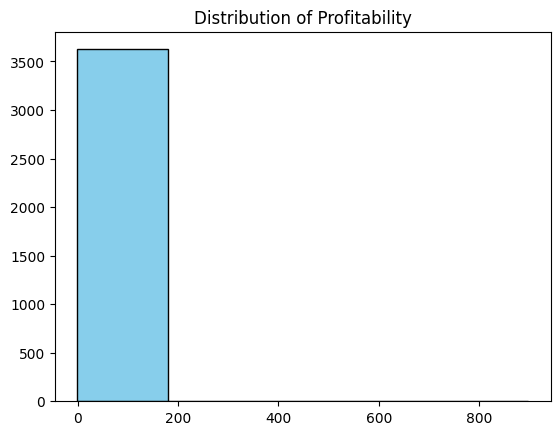

In [25]:
plt.hist(df["profitability"], bins=5, color='skyblue', edgecolor='black')
plt.title("Distribution of Profitability")


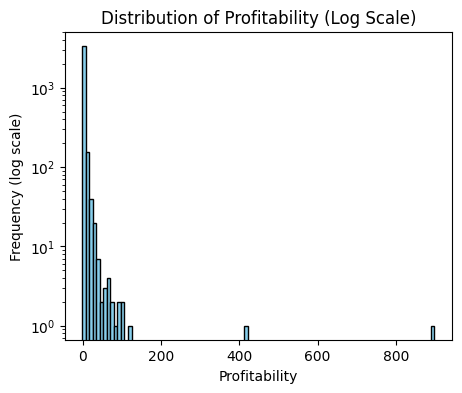

In [32]:
plt.figure(figsize=(5, 4))
plt.hist(df["profitability"], bins=100, color="skyblue", edgecolor="black")
plt.yscale("log")  
plt.xlabel("Profitability")
plt.ylabel("Frequency (log scale)")
plt.title("Distribution of Profitability (Log Scale)")
plt.savefig("Distribution", dpi=2000, bbox_inches='tight')
plt.show()


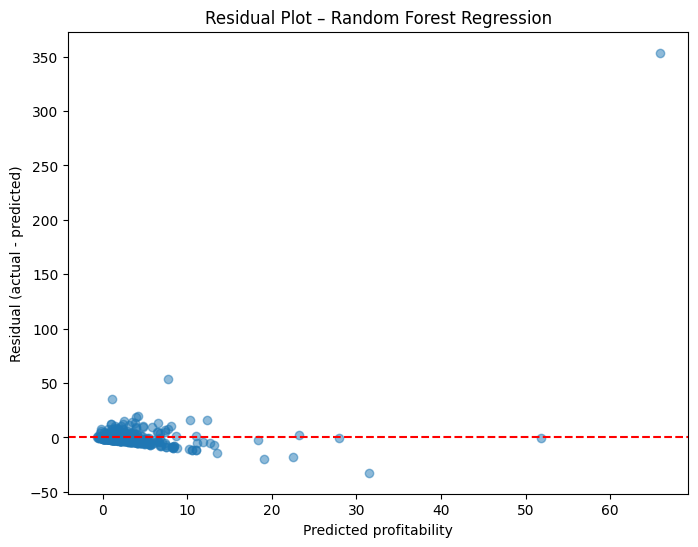

In [21]:
# Residual plot
import matplotlib.pyplot as plt

residuals = y_test_reg - y_pred_reg

plt.figure(figsize=(8, 6))
plt.scatter(y_pred_reg, residuals, alpha=0.5)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Predicted profitability")
plt.ylabel("Residual (actual - predicted)")
plt.title("Residual Plot – Random Forest Regression")
plt.show()


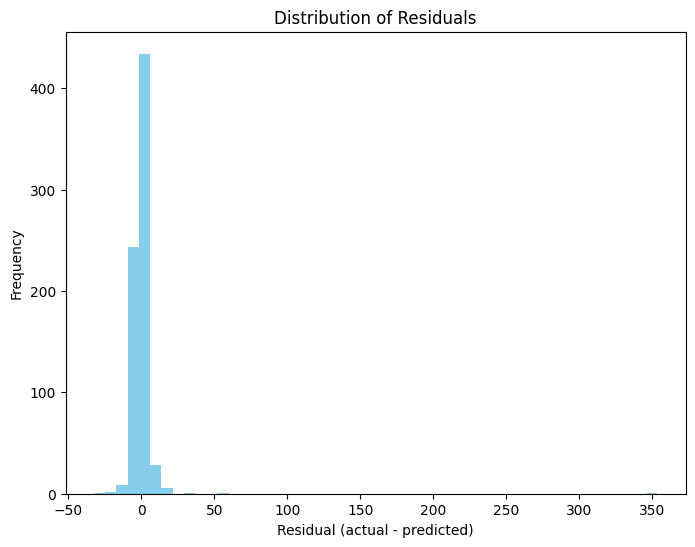

In [22]:
plt.figure(figsize=(8, 6))
plt.hist(residuals, bins=50, color="skyblue")
plt.xlabel("Residual (actual - predicted)")
plt.ylabel("Frequency")
plt.title("Distribution of Residuals")
plt.show()
